#Exercise 03 - XG Boost
Group members:
Elena Niero: 2200437

Eylül Çağla Ersöz: 2185017

Melissa Daniela de Almeida Nespeque: 2183904

Sahasra Sivakumar: 2183897

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.2 MB/s eta 0:00:00


In [ ]:
#all imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
# AdaBoost Algorithm
from sklearn.ensemble import AdaBoostClassifier
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
# XGBoost
import xgboost
from xgboost import XGBClassifier
from xgboost import plot_importance, to_graphviz, plot_tree
print("XGBoost version:",xgboost.__version__)


#3
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

mycmap = "winter"
mpl.rcParams['image.cmap'] = mycmap
plt.rcParams['font.size'] = 13

XGBoost version: 3.2.0


####Generate Data

In [ ]:
# number of data
N=5000
# size of each sample
L=4
# box size
B=100

!mkdir DATA

2 5 1
DATA/x_XGB_26.dat
DATA/y_XGB_26.dat


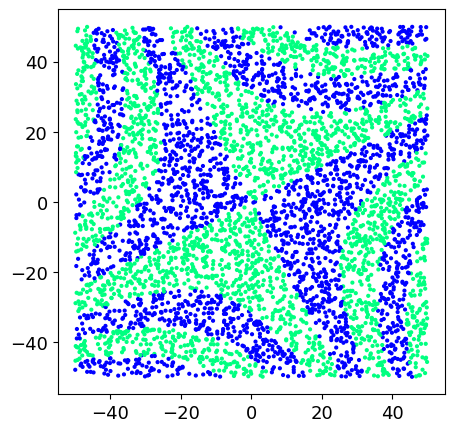

In [ ]:
def f(x):
    Q=np.heaviside(np.sin(np.pi*(x[1]+2*x[0])*(2*x[1]-x[0])/2000),0)
    return Q

def filename(s):
    return "DATA/"+s+".dat"

# random seed for reproducibility
np.random.seed(12345)
print(np.random.randint(0,10),np.random.randint(0,10),np.random.randint(0,10))

x,y = (np.random.random((N,L))-0.5)*B, np.zeros(N).astype(int)
for i in range(N):
    # label data according to a nonlinear function "f" using only the first two features
    y[i] = f(x[i,:2])

plt.figure(figsize = (5,5))
plt.scatter(x[:,0],x[:,1],c=y,s=4,cmap="winter")
plt.show

fn=filename("x_XGB_26")
print(fn)

np.savetxt(fn,x,fmt="%.3f")
fn=filename("y_XGB_26")
np.savetxt(fn,y,fmt="%d")
print(fn)

####Model

####Read and Split

In [ ]:
np.random.seed(12345)

dname="./DATA/"
str0="_XGB_26.dat"
fnamex=dname+'x'+str0
fnamey=dname+'y'+str0
x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
y = np.loadtxt(fnamey)
y = y.astype(int)
N,L = len(x), len(x[0])

N_train = int(0.75*N)
x_train,y_train = x[:N_train],y[:N_train]
x_test,y_test = x[N_train:],y[N_train:]
print(f"N={N}, N_train={N_train}, L={L}")

N=5000, N_train=3750, L=4


####Scatter plot

[-31.608 -29.544   6.773   9.554] 0
[46.451 15.318 24.891 15.357] 0
[ 24.771  46.131 -49.161 -39.356] 0
[-20.13   15.641  30.981  37.218] 0
[46.465 22.369 14.248 21.745] 0


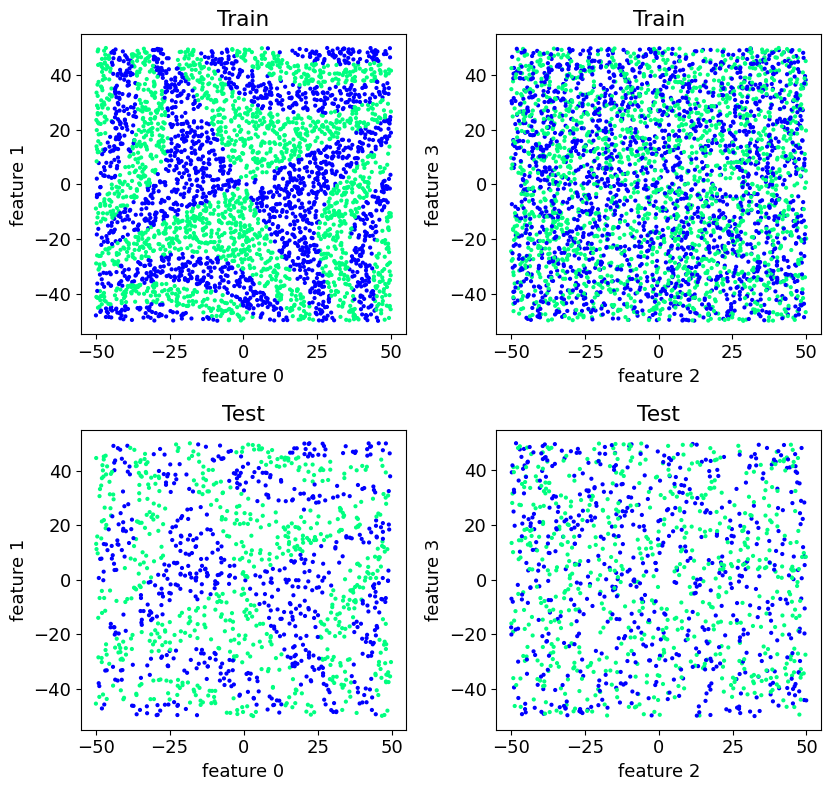

In [ ]:
def scat(ax,x,y,i=0,j=1,s=4,title=""):
    # scatter plot of the data in the plane of features i and j
    ax.scatter(x[:,i],x[:,j],s=s,c=y)
    ax.set_xlabel(f"feature {i}")
    ax.set_ylabel(f"feature {j}")
    ax.set_title(title)

# print the first 5 data points
for n in range(5):
    print(x[n],y[n])

#print feature plots for the training and test sets
fig,AX = plt.subplots(2,2,figsize=(8.5,8.1))
scat(AX[0,0],x_train,y_train,title="Train")
scat(AX[0,1],x_train,y_train,i=2,j=3,title="Train")
scat(AX[1,0],x_test,y_test,title="Test")
scat(AX[1,1],x_test,y_test,i=2,j=3,title="Test")
fig.tight_layout()
plt.show()

def classify(clf=GradientBoostingClassifier(),show=False):
    # GradientBoostingClassifier():
    #   n_estimators = 100 (default)
    #   loss function = deviance(default) used in Logistic Regression
    # XGBClassifier()
    #   n_estimators = 100 (default)
    #   max_depth = 3 (default?)

    clf.fit(x_train,y_train) # train the model on the training set
    y_hat = clf.predict(x_test) # predict the labels of the test set

    print("errors: {:.2f}%   Accuracy={:.3f}".format(100*(1-clf.score(x_test, y_test)),clf.score(x_test, y_test)))
    S=50 # size of the square grid
    dx = 1
    x_seq=np.arange(-S,S+dx,dx) # sequence of points for the grid
    nx = len(x_seq)
    x_plot=np.zeros((nx*nx,L)) # grid of points
    print('shape of x_plot=',x_plot.shape)
    q=0
    for i in range(nx):
        for j in range(nx):
            x_plot[q,:2] = [x_seq[i],x_seq[j]] # only the first two features are used for the artificial grid
            q+=1
    y_plot= clf.predict(x_plot) # predict the labels of the grid points

    fig,AX = plt.subplots(1,2,figsize=(8.2,4))
    scat(AX[0],x_plot[:],y_plot,s=dx,title="predicted")
    scat(AX[1],x_train[:],y_train,title="training set")
    fig.tight_layout()
    plt.show()

    if show:
        dump_list = clf.get_booster().get_dump() # get the list of trees in the model
        num_trees = len(dump_list)
        print("num_trees=",num_trees)

        fig, AX = plt.subplots(2,1,figsize=(12, 5))
        for i in range(min(2,num_trees)):
            ax=AX[i]
            plot_tree(clf, num_trees=i, ax=ax)
        fig.savefig("DATA/tree-classif.png", dpi=400, pad_inches=0.02)
        plt.show()

##1st ex: Model complexity,parameters’ and regularization
Try different parameters (λ, γ, n_estimators, …). Which is the simplest yet effective XGB model that keeps a good validation accuracy? Is regularization useful for this analysis?

In [ ]:
def classify_2(clf=GradientBoostingClassifier(),show=False):

    clf.fit(x_train,y_train)
    y_hat = clf.predict(x_test)

    print("errors: {:.2f}%   Accuracy={:.3f}".format(100*(1-clf.score(x_test, y_test)),clf.score(x_test, y_test)))
    S=50
    dx = 1
    x_seq=np.arange(-S,S+dx,dx)
    nx = len(x_seq)
    x_plot=np.zeros((nx*nx,L))
    print('shape of x_plot=',x_plot.shape)
    q=0
    for i in range(nx):
        for j in range(nx):
            x_plot[q,:2] = [x_seq[i],x_seq[j]]
            q+=1
    y_plot= clf.predict(x_plot)

    if show:
        dump_list = clf.get_booster().get_dump()
        num_trees = len(dump_list)
        print("num_trees=",num_trees)

        fig, AX = plt.subplots(2,1,figsize=(8, 5))
        for i in range(min(2,num_trees)):
            ax=AX[i]
            plot_tree(clf, num_trees=i, ax=ax)
        fig.savefig("DATA/tree-classif.png", dpi=400, pad_inches=0.02)
        plt.show()

    return(100*(1-clf.score(x_test, y_test)),clf.score(x_test, y_test))

**Variation of n_estimators:**

In the below plot we see that the accuracy for the training set goes to 1, while the one for the test set starts to fall after n_estimators = 150. The right number of n_estimators will be around 70.

[ 10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170 180
 190 200 210 220 230 240 250 260 270 280 290 300]


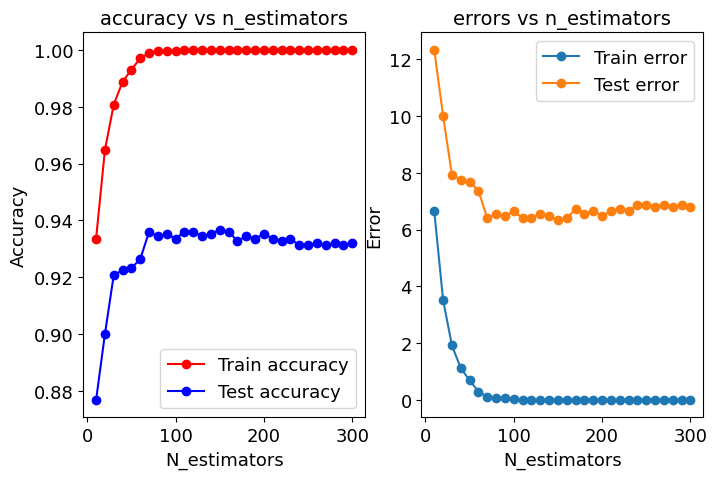

In [ ]:
n_est = np.arange(10, 301, 10)
print(n_est)
err_train = []
err_test = []
acc_train = []
acc_test = []

for i in n_est:
       model = XGBClassifier(seed=1,
                      objective='binary:logistic',
                      importance_type="gain",
                      n_estimators = i)
       model.fit(x_train, y_train)
       #error, accuracy = classify(model, show=False)
       #err.append(error)
       #acc.append(accuracy)
       acc_train.append(model.score(x_train, y_train))
       acc_test.append(model.score(x_test, y_test))
       err_train.append(100*(1-model.score(x_train, y_train)))
       err_test.append(100*(1-model.score(x_test, y_test)))

gridsize = (1,2)
fig = plt.figure(figsize=(8,5))

ax1 = plt.subplot2grid(gridsize, (0, 0), colspan=1, rowspan=1)
ax1.plot(n_est, acc_train, 'o-', c = 'r', label = 'Train accuracy')
ax1.plot(n_est, acc_test, 'o-', c = 'b', label = 'Test accuracy')
ax1.set_xlabel('N_estimators')
ax1.set_ylabel('Accuracy')
ax1.set_title('accuracy vs n_estimators', fontsize=14)
ax1.legend()

ax2 = plt.subplot2grid(gridsize, (0, 1), colspan=1, rowspan=1)
ax2.plot(n_est, err_train, 'o-', label = 'Train error')
ax2.plot(n_est, err_test, 'o-', label = 'Test error')
ax2.set_xlabel('N_estimators')
ax2.set_ylabel('Error')
ax2.set_title('errors vs n_estimators', fontsize=14)
ax2.legend()

**Variation of max_depth**

Max_depth is the parameter that controls the depth of the tree. Increaing it we increase the complexity of the model.

We see that for max_depth > 5 the model goes to overfitting, it becomes too complex. For this reason we will keep max_depth = 5

[0 1 2 3 4 5 6 7 8 9]


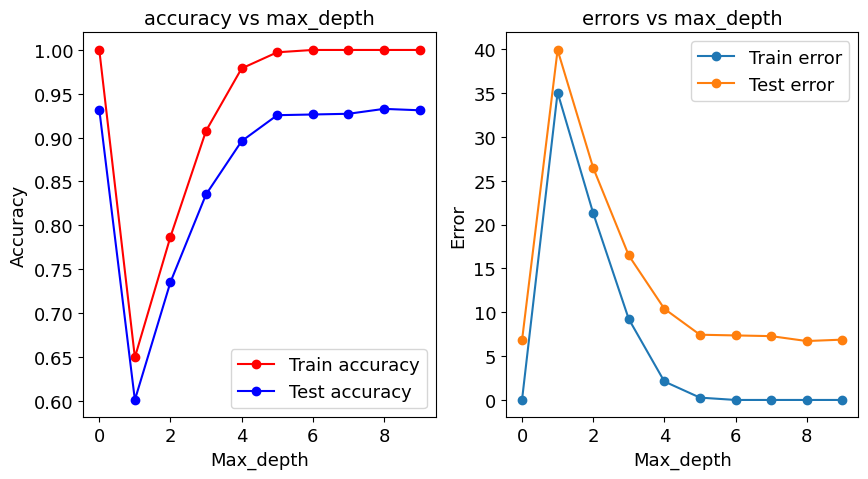

In [ ]:
max_d = np.arange(0, 10, 1)
print(max_d)
err_train = []
err_test = []
acc_train = []
acc_test = []

for i in max_d:
       model = XGBClassifier(seed=1,
                      objective='binary:logistic',
                      importance_type="gain",
                      learning_rate = 0.4,
                      n_estimators = 70,
                      max_depth=i)
       model.fit(x_train, y_train)
       acc_train.append(model.score(x_train, y_train))
       acc_test.append(model.score(x_test, y_test))
       err_train.append(100*(1-model.score(x_train, y_train)))
       err_test.append(100*(1-model.score(x_test, y_test)))

gridsize = (1,2)
fig = plt.figure(figsize=(10,5))

ax1 = plt.subplot2grid(gridsize, (0, 0), colspan=1, rowspan=1)
ax1.plot(max_d, acc_train, 'o-', c = 'r', label = 'Train accuracy')
ax1.plot(max_d, acc_test, 'o-', c = 'b', label = 'Test accuracy')
ax1.set_xlabel('Max_depth')
ax1.set_ylabel('Accuracy')
ax1.set_title('accuracy vs max_depth', fontsize=14)
ax1.legend()

ax2 = plt.subplot2grid(gridsize, (0, 1), colspan=1, rowspan=1)
ax2.plot(max_d, err_train, 'o-', label = 'Train error')
ax2.plot(max_d, err_test, 'o-', label = 'Test error')
ax2.set_xlabel('Max_depth')
ax2.set_ylabel('Error')
ax2.set_title('errors vs max_depth', fontsize=14)
ax2.legend()

**Variation of reg_lambda**

Increasing reg_lambda we force the model to be more conservative and more simple. So regularization is useful in this cases to avoid overftitting. Here we take a model that will overfit (as max_depth = 10) and we want to see how this model behaves increasing the value of reg_lambda.

[ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46
 48 50 52 54 56 58 60 62 64 66 68]


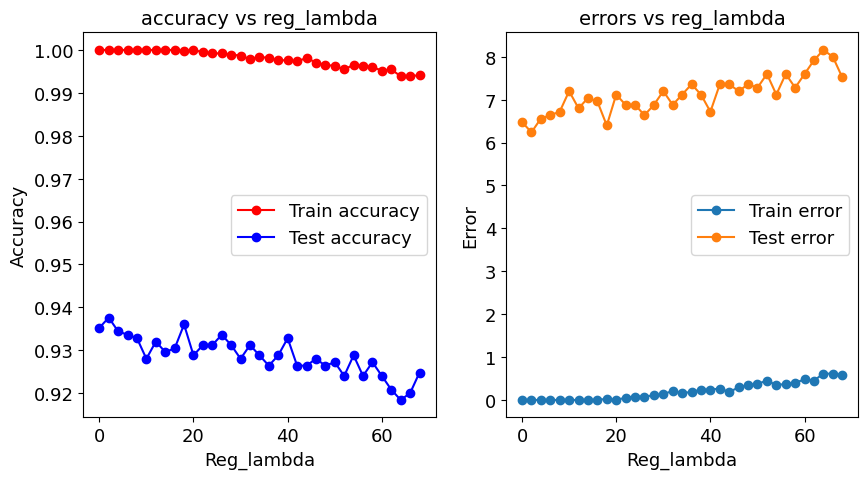

In [ ]:
reg = np.arange(0, 70, 2)
print(reg)
err_train = []
err_test = []
acc_train = []
acc_test = []

gridsize = (1,2)
fig = plt.figure(figsize=(10,5))

for i in reg:
       model = XGBClassifier(seed=1,
                      objective='binary:logistic',
                      importance_type="gain",
                      learning_rate = 0.4,
                      reg_lambda = i,
                      n_estimators = 100,
                      max_depth = 10)
       model.fit(x_train, y_train)
       acc_train.append(model.score(x_train, y_train))
       acc_test.append(model.score(x_test, y_test))
       err_train.append(100*(1-model.score(x_train, y_train)))
       err_test.append(100*(1-model.score(x_test, y_test)))


ax1 = plt.subplot2grid(gridsize, (0, 0), colspan=1, rowspan=1)
ax1.plot(reg, acc_train, 'o-', c = 'r', label = 'Train accuracy')
ax1.plot(reg, acc_test, 'o-', c = 'b', label = 'Test accuracy')
ax1.set_xlabel('Reg_lambda')
ax1.set_ylabel('Accuracy')
ax1.set_title('accuracy vs reg_lambda', fontsize=14)
ax1.legend()

ax2 = plt.subplot2grid(gridsize, (0, 1), colspan=1, rowspan=1)
ax2.plot(reg, err_train, 'o-', label = 'Train error')
ax2.plot(reg, err_test, 'o-', label = 'Test error')
ax2.set_xlabel('Reg_lambda')
ax2.set_ylabel('Error')
ax2.set_title('errors vs reg_lambda', fontsize=14)
ax2.legend()

##2nd Ex: Dimensionality reduction
Consider reduced data samples with L’<L features. For example, feature 0,1, and 3 out of the L=4
features.
Check if the exclusion of the least important feature(s) from training data leads to better accuracy.

From the result:
| Combination | Features | Accuracy |
| :--- | :--- | :--- |
| All | [0, 1, 2, 3] | 0.9232 |
| 0, 1, 3 | [0, 1, 3] | 0.9184 |

We can understand that XGB trained on all the features and the features with [0,1,3] performs well.

In [ ]:
def reduced_data(indices, x_tr, x_te):
    return x_tr[:, indices], x_te[:, indices]

feature_set = {
    'All': [0, 1, 2, 3],
    '0,1': [0, 1],
    '1, 2': [1, 2],
    '0, 2': [0, 2],
    '0, 1, 3': [0, 1, 3],
    '1, 2, 3': [1, 2, 3],
    '0, 2, 3': [0, 2, 3]
}

results = []

for name, cols in feature_set.items():
    x_red_train, x_red_test = reduced_data(cols, x_train, x_test)
    xgb_params = {
        'n_estimators': 369, 'max_depth': 12, 'learning_rate': 0.01957,
        'subsample': 0.83, 'colsample_bytree': 0.77, 'gamma': 0.67,
        'objective': 'binary:logistic', 'random_state': 1, 'n_jobs': -1
    }
    model = xgb.XGBClassifier(**xgb_params)
    model.fit(x_red_train, y_train)

    preds = model.predict(x_red_test)
    acc = accuracy_score(y_test, preds)

    results.append({"Combination": name, "Features": cols, "Accuracy": acc})

df_results = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print(df_results)

  Combination      Features  Accuracy
0         All  [0, 1, 2, 3]    0.9232
4     0, 1, 3     [0, 1, 3]    0.9184
1         0,1        [0, 1]    0.6216
3        0, 2        [0, 2]    0.6152
2        1, 2        [1, 2]    0.6008
6     0, 2, 3     [0, 2, 3]    0.5856
5     1, 2, 3     [1, 2, 3]    0.5792


##3rd Ex:XGBoost vs NN
Compare the validation accuracy of XGB with that of a simple feed-forward neural network (FFNN)
•By varying the number of data samples N’ in the training set (i.e., reducing the fraction N’/N of
the data set used for training)
•With cross-validation for all cases.
Is the FFNN or the XGB performing significantly better at low N’?

First we build the FFNN, we applied tanh instead of relu because it performs better. Then we used the best performing XGB (found using optuna) and used a for loop to iterate for each fraction of data that we want to test. Below are the results.

 | Frac       N |   XGB mean    ±std |  FFNN mean |  ±std | Winner|
 |--------------|--------------------|------------|-------|-------|
 | 0.05     187 |     0.5940  0.0379 |     0.4922 | 0.0485 | XGB|
 | 0.10     375 |     0.7013  0.0550 |     0.5520 | 0.0261 | XGB |
 | 0.20     750 |     0.7533  0.0219 |     0.5453 | 0.0268 | XGB |
 | 0.30    1125 |     0.8267  0.0256 |     0.5156 | 0.0149 | XGB |
 | 0.40    1500 |     0.8640  0.0147 |     0.5180 | 0.0198 | XGB |
 | 0.50    1875 |     0.8821  0.0183 |     0.6368 | 0.1254 | XGB |
 | 0.60    2250 |     0.8911  0.0133 |     0.5996 | 0.1588 | XGB |
 | 0.70    2625 |     0.9090  0.0092 |     0.6008 | 0.1612 | XGB |
 | 0.80    3000 |     0.9133  0.0094 |     0.6817 | 0.2086 | XGB |
 | 0.90    3375 |     0.9241  0.0137 |     0.7627 | 0.2135 | XGB |
 | 1.00    3750 |     0.9229  0.0076 |     0.9531 | 0.0111 | FFNN |

 As expected FFNN performs well only when we provide large number of data, which can be reasoned with the fact that FFNN being a complex model tends to overfit with small amount of data. XGB on other hand hits 90% accuracy from 70% of the data.

####FFNN model

In [ ]:
scaler  = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)

model = MLPClassifier(
    hidden_layer_sizes = (256, 128, 64, 32),  # 4 hidden layers
    activation         = 'tanh',              # tanh works better than relu for sinusoidal boundaries
    solver             = 'adam',
    alpha              = 1e-4,                # L2
    learning_rate_init = 1e-3,
    max_iter           = 500,
    early_stopping     = True,                # to avoid overfit
    validation_fraction= 0.1,
    n_iter_no_change   = 20,
    random_state       = 42,
    verbose            = True
)

model.fit(x_train, y_train)
preds = model.predict(x_test)
acc   = accuracy_score(y_test, preds)
print(f"\nTest accuracy: {acc:.4f}")
print(classification_report(y_test, preds))

Iteration 1, loss = 0.69893582
Validation score: 0.528000
Iteration 2, loss = 0.69805154
Validation score: 0.477333
Iteration 3, loss = 0.69737823
Validation score: 0.506667
Iteration 4, loss = 0.69348234
Validation score: 0.528000
Iteration 5, loss = 0.69385119
Validation score: 0.490667
Iteration 6, loss = 0.69458843
Validation score: 0.517333
Iteration 7, loss = 0.69488101
Validation score: 0.509333
Iteration 8, loss = 0.69424980
Validation score: 0.485333
Iteration 9, loss = 0.69378411
Validation score: 0.506667
Iteration 10, loss = 0.69289727
Validation score: 0.520000
Iteration 11, loss = 0.69154698
Validation score: 0.517333
Iteration 12, loss = 0.69032968
Validation score: 0.490667
Iteration 13, loss = 0.69073718
Validation score: 0.474667
Iteration 14, loss = 0.68806688
Validation score: 0.488000
Iteration 15, loss = 0.68543369
Validation score: 0.506667
Iteration 16, loss = 0.68169225
Validation score: 0.504000
Iteration 17, loss = 0.67881526
Validation score: 0.538667
Iterat

####Finding best hyperparameters for XGB using optuna

In [ ]:
def objective(trial, X, y):
    # Define the search space
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),

        # Fixed parameters from your snippet
        'objective': 'binary:logistic',
        'importance_type': 'gain',
        'random_state': 1,
        'n_jobs': -1
    }
    model = xgb.XGBClassifier(**param)

    # Using 5-fold cross-validation
    score = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()
    return score

In [ ]:
scaler  = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)
#Create the study
study = optuna.create_study(direction='maximize')
#Run optimization (X and y come from your data generation)
study.optimize(lambda trial: objective(trial, x_train, y_train), n_trials=50)
#Results
print(f"Best Accuracy: {study.best_value:.4f}")
print("Best Params:", study.best_params)
best_model = xgb.XGBClassifier(**study.best_params, objective='binary:logistic', importance_type='gain', random_state=1)
best_model.fit(x_train, y_train)
#Predict the test data
y_pred = best_model.predict(x_test)
#Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
#Generate a classification report
cr = classification_report(y_test, y_pred)
print(f"\nReport:\n{cr}")

[I 2026-03-23 08:52:38,174] A new study created in memory with name: no-name-e280d397-37e6-484f-904d-97457a291ec5
[I 2026-03-23 08:52:38,454] Trial 0 finished with value: 0.6629333333333334 and parameters: {'n_estimators': 81, 'max_depth': 3, 'learning_rate': 0.020062552972209054, 'subsample': 0.8386820099770322, 'colsample_bytree': 0.7067088516388452, 'gamma': 9.044983880494224e-07, 'min_child_weight': 2}. Best is trial 0 with value: 0.6629333333333334.
[I 2026-03-23 08:52:39,405] Trial 1 finished with value: 0.7496 and parameters: {'n_estimators': 386, 'max_depth': 4, 'learning_rate': 0.05044787145657427, 'subsample': 0.55534229006257, 'colsample_bytree': 0.5206161365743175, 'gamma': 2.0581776355267635e-05, 'min_child_weight': 6}. Best is trial 1 with value: 0.7496.
[I 2026-03-23 08:52:41,628] Trial 2 finished with value: 0.8602666666666666 and parameters: {'n_estimators': 447, 'max_depth': 8, 'learning_rate': 0.01766322209512316, 'subsample': 0.7386104626657173, 'colsample_bytree': 

Best Accuracy: 0.9248
Best Params: {'n_estimators': 223, 'max_depth': 12, 'learning_rate': 0.09803132321655762, 'subsample': 0.9316168071035686, 'colsample_bytree': 0.8068996149592425, 'gamma': 3.119601187602549e-06, 'min_child_weight': 1}
Accuracy: 0.9328

Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       603
           1       0.95      0.92      0.93       647

    accuracy                           0.93      1250
   macro avg       0.93      0.93      0.93      1250
weighted avg       0.93      0.93      0.93      1250



####Comparison

In [ ]:
N, L    = len(x), len(x[0])
N_train = int(0.75 * N)
x_train_full, y_train_full = x[:N_train], y[:N_train]
x_test,y_test= x[N_train:], y[N_train:]

fractions = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_params = {
    'n_estimators':     369,
    'max_depth':        12,
    'learning_rate':    0.019572493024485386,
    'subsample':        0.8376413540481072,
    'colsample_bytree': 0.7750043951069051,
    'gamma':            0.6772280718914677,
    'min_child_weight': 1,
    'objective':        'binary:logistic',
    'random_state':     1,
    'n_jobs':           -1,
}

results = []

for frac in fractions:
    n_samples = max(50, int(frac * N_train))
    x_tr = x_train_full[:n_samples]
    y_tr = y_train_full[:n_samples]

    xgb_cv, ffnn_cv = [], []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(x_tr, y_tr)):
        x_fold_tr, x_fold_val = x_tr[train_idx], x_tr[val_idx]
        y_fold_tr, y_fold_val = y_tr[train_idx], y_tr[val_idx]

        #xgb
        xgb_model = xgb.XGBClassifier(**xgb_params)
        xgb_model.fit(x_fold_tr, y_fold_tr)
        xgb_cv.append(accuracy_score(y_fold_val, xgb_model.predict(x_fold_val)))

        #ffnn
        scaler = StandardScaler()
        x_fold_tr_s = scaler.fit_transform(x_fold_tr)
        x_fold_val_s = scaler.transform(x_fold_val)

        ffnn = MLPClassifier(
            hidden_layer_sizes  = (256, 128, 64, 32),
            activation          = 'tanh',
            solver              = 'adam',
            alpha               = 1e-4,
            learning_rate_init  = 1e-3,
            max_iter            = 500,
            early_stopping      = True,
            validation_fraction = 0.1,
            n_iter_no_change    = 20,
            random_state        = 42,
        )
        ffnn.fit(x_fold_tr_s, y_fold_tr)
        ffnn_cv.append(accuracy_score(y_fold_val, ffnn.predict(x_fold_val_s)))

    results.append({
        'frac':     frac,
        'n':        n_samples,
        'xgb_mean': np.mean(xgb_cv),
        'xgb_std':  np.std(xgb_cv),
        'ffnn_mean': np.mean(ffnn_cv),
        'ffnn_std':  np.std(ffnn_cv),
    })

    print(f"frac={frac:.2f}  N'={n_samples:5d} | "
          f"XGB  {np.mean(xgb_cv):.4f} ± {np.std(xgb_cv):.4f} | "
          f"FFNN {np.mean(ffnn_cv):.4f} ± {np.std(ffnn_cv):.4f}")

# result
print(f"\n{'Frac':>6} {'N':>7} | {'XGB mean':>10} {'±std':>7} | {'FFNN mean':>10} {'±std':>7} | Winner")
print("-" * 72)
for r in results:
    winner = "XGB" if r['xgb_mean'] > r['ffnn_mean'] else "FFNN"
    print(f"{r['frac']:6.2f} {r['n']:7d} | "
          f"{r['xgb_mean']:10.4f} {r['xgb_std']:7.4f} | "
          f"{r['ffnn_mean']:10.4f} {r['ffnn_std']:7.4f} | {winner}")

frac=0.05  N'=  187 | XGB  0.5940 ± 0.0379 | FFNN 0.4922 ± 0.0485
frac=0.10  N'=  375 | XGB  0.7013 ± 0.0550 | FFNN 0.5520 ± 0.0261
frac=0.20  N'=  750 | XGB  0.7533 ± 0.0219 | FFNN 0.5453 ± 0.0268
frac=0.30  N'= 1125 | XGB  0.8267 ± 0.0256 | FFNN 0.5156 ± 0.0149
frac=0.40  N'= 1500 | XGB  0.8640 ± 0.0147 | FFNN 0.5180 ± 0.0198
frac=0.50  N'= 1875 | XGB  0.8821 ± 0.0183 | FFNN 0.6368 ± 0.1254
frac=0.60  N'= 2250 | XGB  0.8911 ± 0.0133 | FFNN 0.5996 ± 0.1588
frac=0.70  N'= 2625 | XGB  0.9090 ± 0.0092 | FFNN 0.6008 ± 0.1612
frac=0.80  N'= 3000 | XGB  0.9133 ± 0.0094 | FFNN 0.6817 ± 0.2086
frac=0.90  N'= 3375 | XGB  0.9241 ± 0.0137 | FFNN 0.7627 ± 0.2135
frac=1.00  N'= 3750 | XGB  0.9229 ± 0.0076 | FFNN 0.9531 ± 0.0111

  Frac       N |   XGB mean    ±std |  FFNN mean    ±std | Winner
------------------------------------------------------------------------
  0.05     187 |     0.5940  0.0379 |     0.4922  0.0485 | XGB
  0.10     375 |     0.7013  0.0550 |     0.5520  0.0261 | XGB
  0.20  